In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
from datetime import datetime
from scipy.optimize import curve_fit

import libreria_funzioni_utili as lfu
import libreria_Model_Tournament as lmt

DATA_MISURA = "2026-05-11"

# Dizionario con VITE MEDIE (tau) in anni
INFO_SORGENTI = {
    '22Na':  {'A0': 62836,  'data_cal': '2025-10-15', 'tau_anni': 3.75,  
              'Br': {511.0: 1.798, 1274.5: 0.999}, 'file': 'dati_1ora_Na_0019_20260425_104454', 't_live_ms': 3582544},
    '60Co':  {'A0': 121345, 'data_cal': '2025-10-15', 'tau_anni': 7.60, 
              'Br': {1173.2: 0.998, 1332.5: 0.999}, 'file': 'dati_1ora_Co_0021_20260501_104027', 't_live_ms': 3560573},
    '228Th': {'A0': 9663,   'data_cal': '2025-10-15', 'tau_anni': 2.74, 
              'Br': {2614.5: 0.359}, 'file': 'dati_1ora_Th_0021_20260505_103813', 't_live_ms': 3592414}
}

def get_attivita_oggi(isoid, data_oggi):
    s = INFO_SORGENTI[isoid]
    
    # 1. Calcolo i giorni passati tra calibrazione e oggi
    dt_giorni = (datetime.strptime(data_oggi, '%Y-%m-%d') - datetime.strptime(s['data_cal'], '%Y-%m-%d')).days
    
    # 2. Converto la vita media da anni a giorni
    tau_giorni = s['tau_anni'] * 365.25
    
    # 3. Formula con vita media: A = A0 * exp(-t / tau)
    return s['A0'] * np.exp(-dt_giorni / tau_giorni)

In [5]:
# Parametri di calibrazione (facilmente modificabili)
CALIB = {
    'm': 0.17612871788284507,
    'q': -12.467602270278535,
    'err_m': 2.9441801319008697e-06,
    'err_q': 0.018189694011750676
}

# Funzione veloce per calibrare un array di canali
def calibra_canali(ch_array):
    return CALIB['m'] * ch_array + CALIB['q']

In [6]:
import numpy as np

# Caricamento del file (singola colonna di conteggi)
data_na = np.loadtxt('dati_1ora_Na_0019_20260425_104454.dat')
data_co = np.loadtxt('dati_1ora_Co_0021_20260501_104027.dat')
data_th = np.loadtxt('dati_1ora_Th_0021_20260505_103813.dat')

# Creiamo l'asse x (i canali) da 0 a N-1
channels_na = np.arange(len(data_na))
channels_co = np.arange(len(data_co))
channels_th = np.arange(len(data_th))

print(f"Caricamento completato!")
print(f"Sodio:   {len(data_na)} canali.")
print(f"Cobalto: {len(data_co)} canali.")
print(f"Torio: {len(data_th)} canali.")

Caricamento completato!
Sodio:   8192 canali.
Cobalto: 8192 canali.
Torio: 8192 canali.


--- Analisi Sodio-22 (SUI CANALI) ---
 RICERCA AUTOMATICA DEI PICCHI COMPLETATA
Trovato Picco 1 a canale: 2975 (Altezza: 5533)
Trovato Picco 2 a canale: 7310 (Altezza: 2155)



 PIPELINE PICCO: Picco 2975 keV (Sodio-22) (Canale ~2975)
[FASE 1] Esecuzione Pre-Fit (Gaussiana + Retta)...
[FASE 2] Torneo del Background (con Mascheramento del picco)...
  - B1: BIC = 99.85 (Parametri liberi: 1)
  - B2: BIC = 38.01 (Parametri liberi: 2)
  - B3: BIC = 36.21 (Parametri liberi: 2)
  - B4: BIC = 39.14 (Parametri liberi: 3)
  => VINCITORE BACKGROUND (Minimo BIC): B3

[FASE 3] Torneo del Picco (Soft Constraints sul Background)...
  - Test Coda ICC (P2 vs P1): p-value = 1.0296 % -> SIGNIFICATIVA
  - Test Coda Pile-up (P3 vs P1): p-value = 0.7316 % -> SIGNIFICATIVO
  => VINCITORE PICCO: P4

[FASE 4] Fit Globale di Rifinitura...

--- RISULTATI DEFINITIVI Picco 2975 keV (Sodio-22) ---
Modello Combinato       : Gaussiana + Coda SX + Coda DX + Costante + Gradino
Centroide               : 2975.64 ± 0.09 c

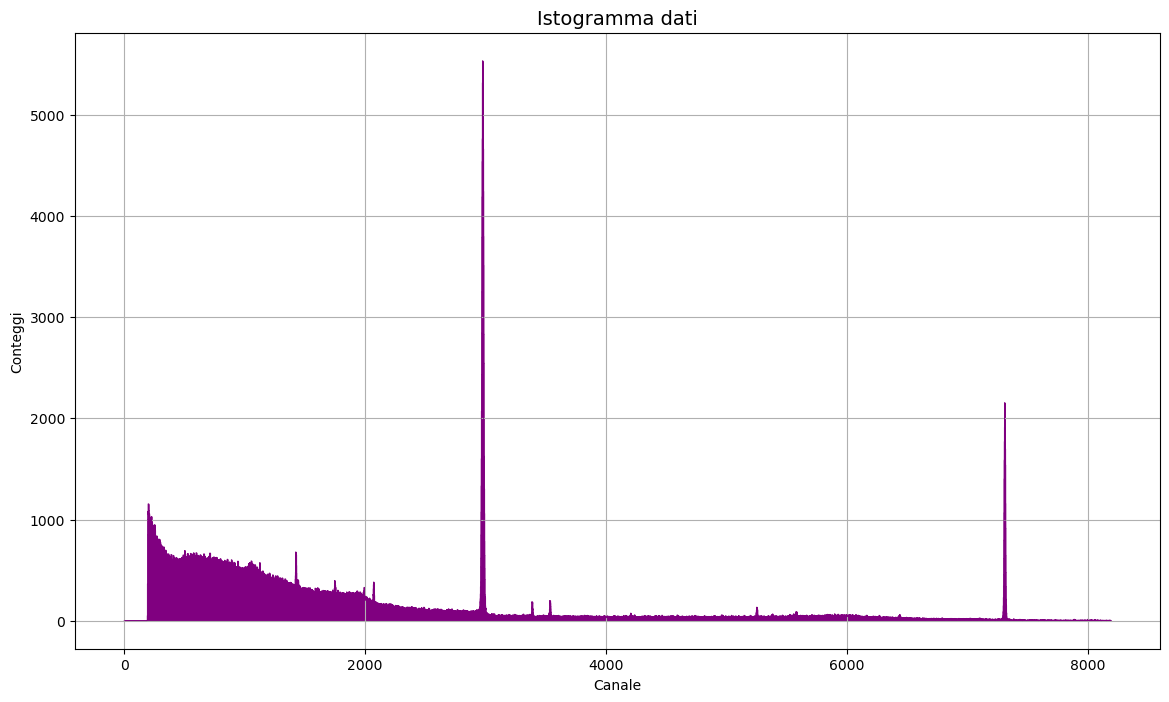

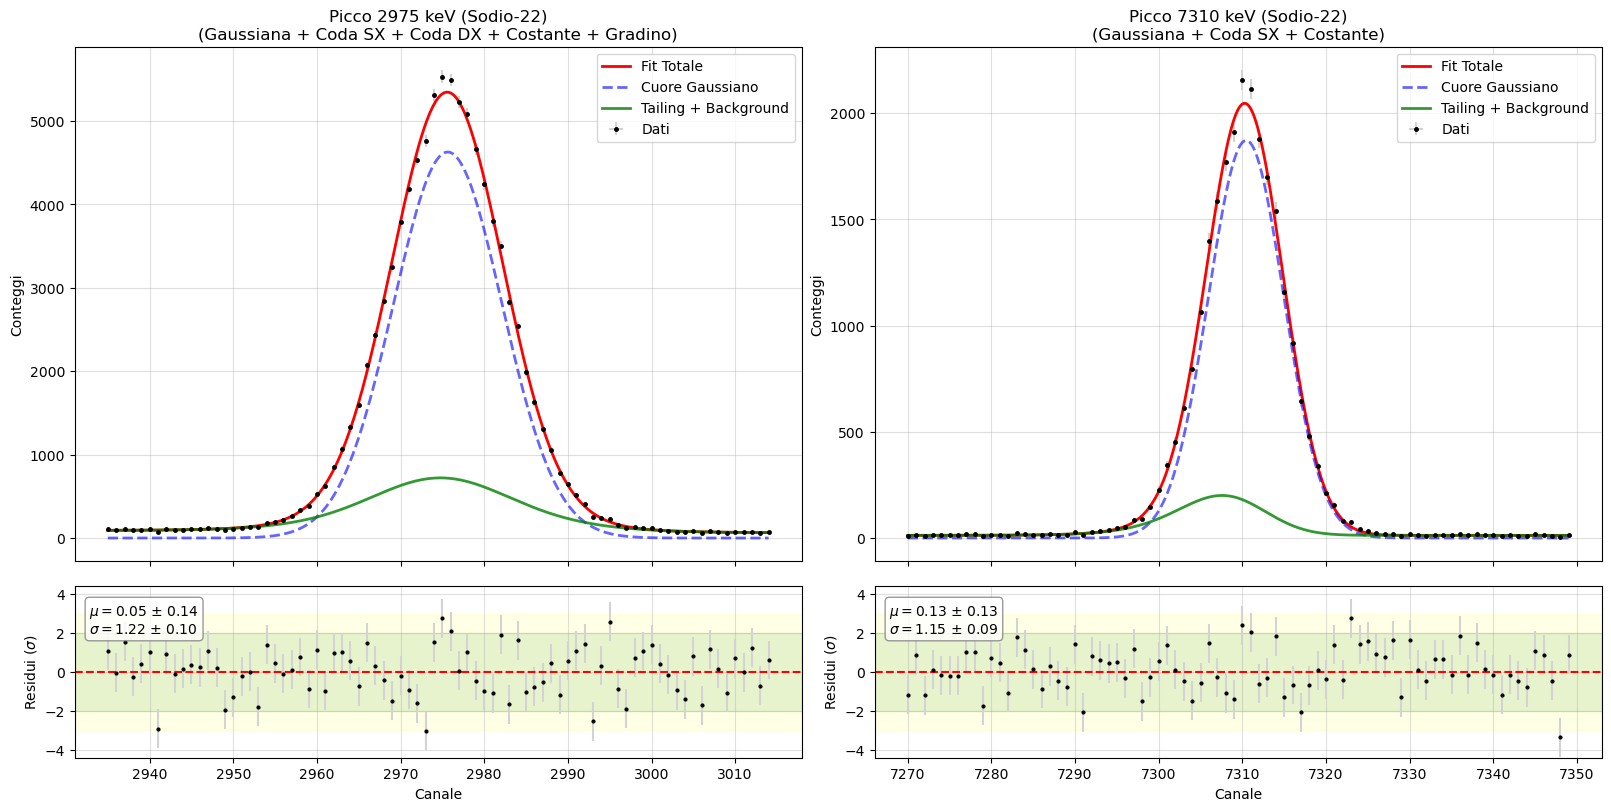


--- Analisi Cobalto-60 (SUI CANALI) ---
 RICERCA AUTOMATICA DEI PICCHI COMPLETATA
Trovato Picco 1 a canale: 6742 (Altezza: 9789)
Trovato Picco 2 a canale: 7641 (Altezza: 8119)



 PIPELINE PICCO: Picco 6742 keV (Cobalto-60) (Canale ~6742)
[FASE 1] Esecuzione Pre-Fit (Gaussiana + Retta)...
[FASE 2] Torneo del Background (con Mascheramento del picco)...
  - B1: BIC = 192.87 (Parametri liberi: 1)
  - B2: BIC = 162.27 (Parametri liberi: 2)
  - B3: BIC = 155.51 (Parametri liberi: 2)
  - B4: BIC = 155.18 (Parametri liberi: 3)
  => VINCITORE BACKGROUND (Minimo BIC): B4

[FASE 3] Torneo del Picco (Soft Constraints sul Background)...
  - Test Coda ICC (P2 vs P1): p-value = 0.0000 % -> SIGNIFICATIVA
  - Test Coda Pile-up (P3 vs P1): p-value = 0.1317 % -> SIGNIFICATIVO
  => VINCITORE PICCO: P4

[FASE 4] Fit Globale di Rifinitura...

--- RISULTATI DEFINITIVI Picco 6742 keV (Cobalto-60) ---
Modello Combinato       : Gaussiana + Coda SX + Coda DX + Retta + Gradino
Centroide               : 6741.62 

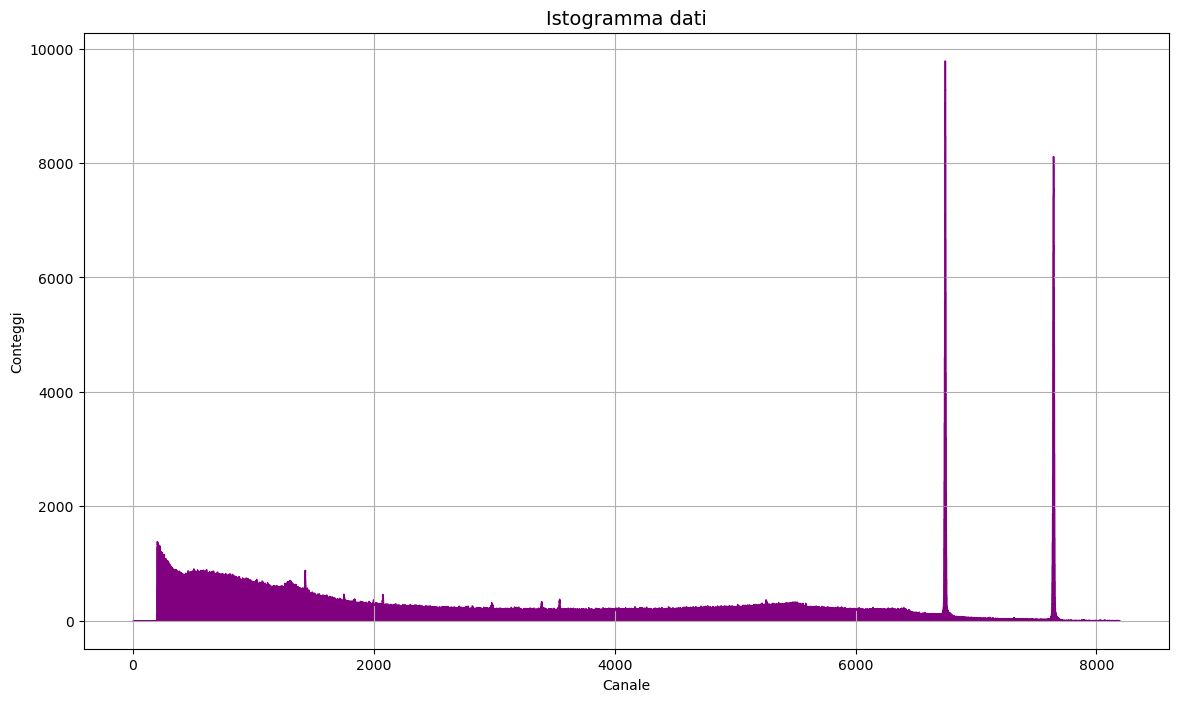

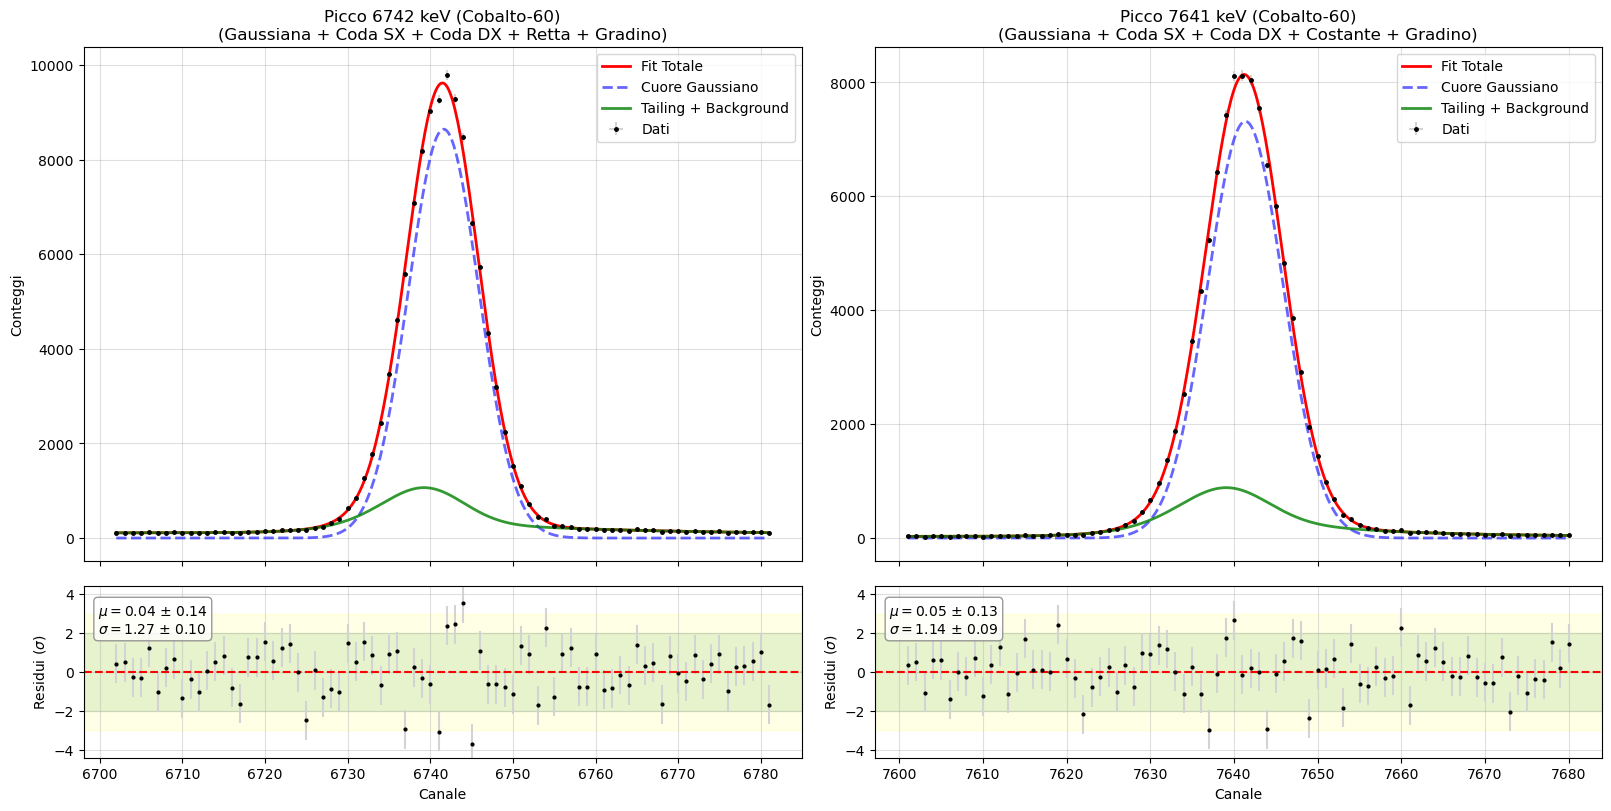


--- Analisi Torio-228 Parte 1 ---
 RICERCA AUTOMATICA DEI PICCHI COMPLETATA
Trovato Picco 1 a canale: 1421 (Altezza: 604)
Trovato Picco 2 a canale: 1742 (Altezza: 172)



 PIPELINE PICCO: Picco 238 keV (Torio-228 Parte 1) (Canale ~1421)
[FASE 1] Esecuzione Pre-Fit (Gaussiana + Retta)...
[FASE 2] Torneo del Background (con Mascheramento del picco)...
  - B1: BIC = 181.41 (Parametri liberi: 1)
  - B2: BIC = 134.84 (Parametri liberi: 2)
  - B3: BIC = 153.46 (Parametri liberi: 2)
  - B4: BIC = 111.25 (Parametri liberi: 3)
  => VINCITORE BACKGROUND (Minimo BIC): B4

[FASE 3] Torneo del Picco (Soft Constraints sul Background)...
  - Test Coda ICC (P2 vs P1): p-value = 5.2066 % -> Trascurabile
  - Test Coda Pile-up (P3 vs P1): p-value = 18.2015 % -> Trascurabile
  => VINCITORE PICCO: P1

[FASE 4] Fit Globale di Rifinitura...

--- RISULTATI DEFINITIVI Picco 238 keV (Torio-228 Parte 1) ---
Modello Combinato       : Gaussiana Pura + Retta + Gradino
Centroide               : 1419.74 ± 0.10 ch
FW

c:\Users\Anna\Desktop\Laboratorio Nucleare\labnuc_lib\Efficienza\libreria_Model_Tournament.py:451: RuntimeWarning: divide by zero encountered in log
  bic = m_B.fval + k * np.log(len(x_mask))
c:\Users\Anna\anaconda3\Lib\site-packages\iminuit\cost.py:2542: RuntimeWarning: divide by zero encountered in divide
  return np.linalg.inv(array) if array.ndim == 2 else 1.0 / array
c:\Users\Anna\anaconda3\Lib\site-packages\iminuit\cost.py:2479: RuntimeWarning: invalid value encountered in multiply
  return np.sum(delta**2 * self._covinv)


  - Test Coda ICC (P2 vs P1): p-value = 100.0000 % -> Trascurabile
  - Test Coda Pile-up (P3 vs P1): p-value = 100.0000 % -> Trascurabile
  => VINCITORE PICCO: P1

[FASE 4] Fit Globale di Rifinitura...
  [Attenzione FWHM] Matrice di covarianza instabile, troppi fallimenti nel MC.
  [Attenzione AREA] Matrice di covarianza instabile, troppi fallimenti nel MC.

--- RISULTATI DEFINITIVI Picco 295 keV (Torio-228 Parte 1) ---
Modello Combinato       : Gaussiana Pura + Costante
Centroide               : 270.48 ± 9318.98 ch
FWHM (da sigma)         : 680.5738 ± 819.7758 ch
FWHM (effettiva)        : 39.8832 ± 0.0000 ch
FWHM (eff. relativa %)  : 14.74510 ± 508.01168 %
Area Netta              : 34613.0 ± 0.0 conteggi
Chi2 / ndof             : 314.7 / 76 = 4.14
p-value del fit         : 0.0000 %


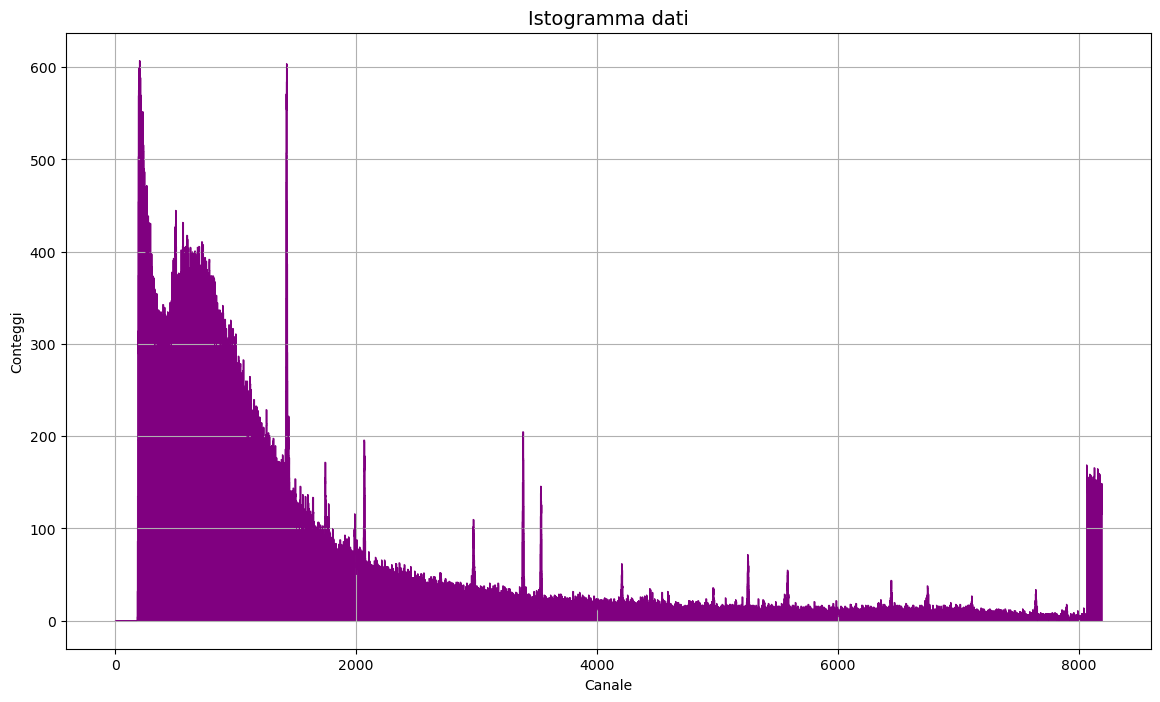

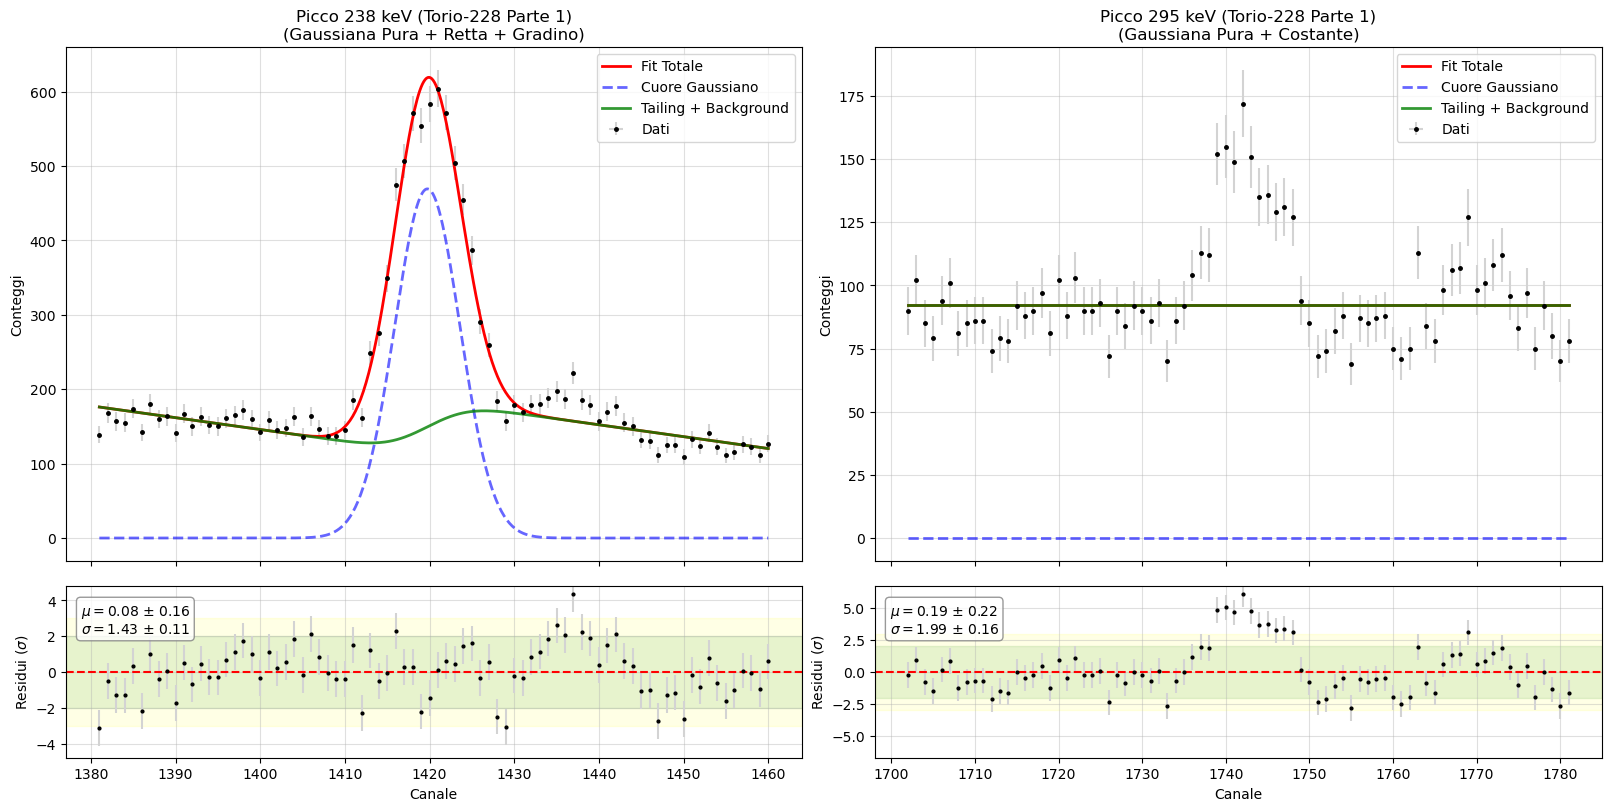


--- Analisi Torio-228 Parte 2 ---
 RICERCA AUTOMATICA DEI PICCHI COMPLETATA
Trovato Picco 1 a canale: 2065 (Altezza: 196)
Trovato Picco 2 a canale: 2972 (Altezza: 110)
Trovato Picco 3 a canale: 3385 (Altezza: 205)
Trovato Picco 4 a canale: 3533 (Altezza: 146)
Trovato Picco 5 a canale: 8064 (Altezza: 169)



 PIPELINE PICCO: Picco 351 keV (Torio-228 Parte 2) (Canale ~2065)
[FASE 1] Esecuzione Pre-Fit (Gaussiana + Retta)...
[FASE 2] Torneo del Background (con Mascheramento del picco)...
  - B1: BIC = 76.60 (Parametri liberi: 1)
  - B2: BIC = 75.03 (Parametri liberi: 2)
  - B3: BIC = 74.13 (Parametri liberi: 2)
  - B4: BIC = 78.32 (Parametri liberi: 3)
  => VINCITORE BACKGROUND (Minimo BIC): B3

[FASE 3] Torneo del Picco (Soft Constraints sul Background)...
  - Test Coda ICC (P2 vs P1): p-value = 99.9827 % -> Trascurabile
  - Test Coda Pile-up (P3 vs P1): p-value = 100.0000 % -> Trascurabile
  => VINCITORE PICCO: P1

[FASE 4] Fit Globale di Rifinitura...

--- RISULTATI DEFINITIVI Picco 3

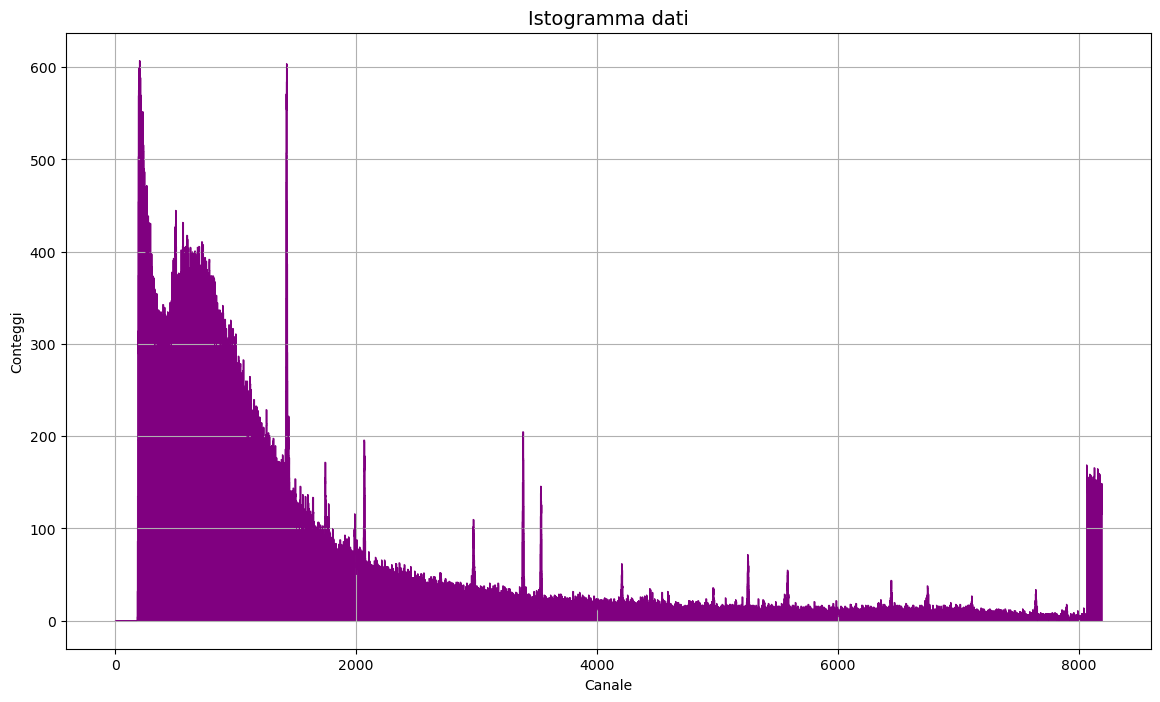

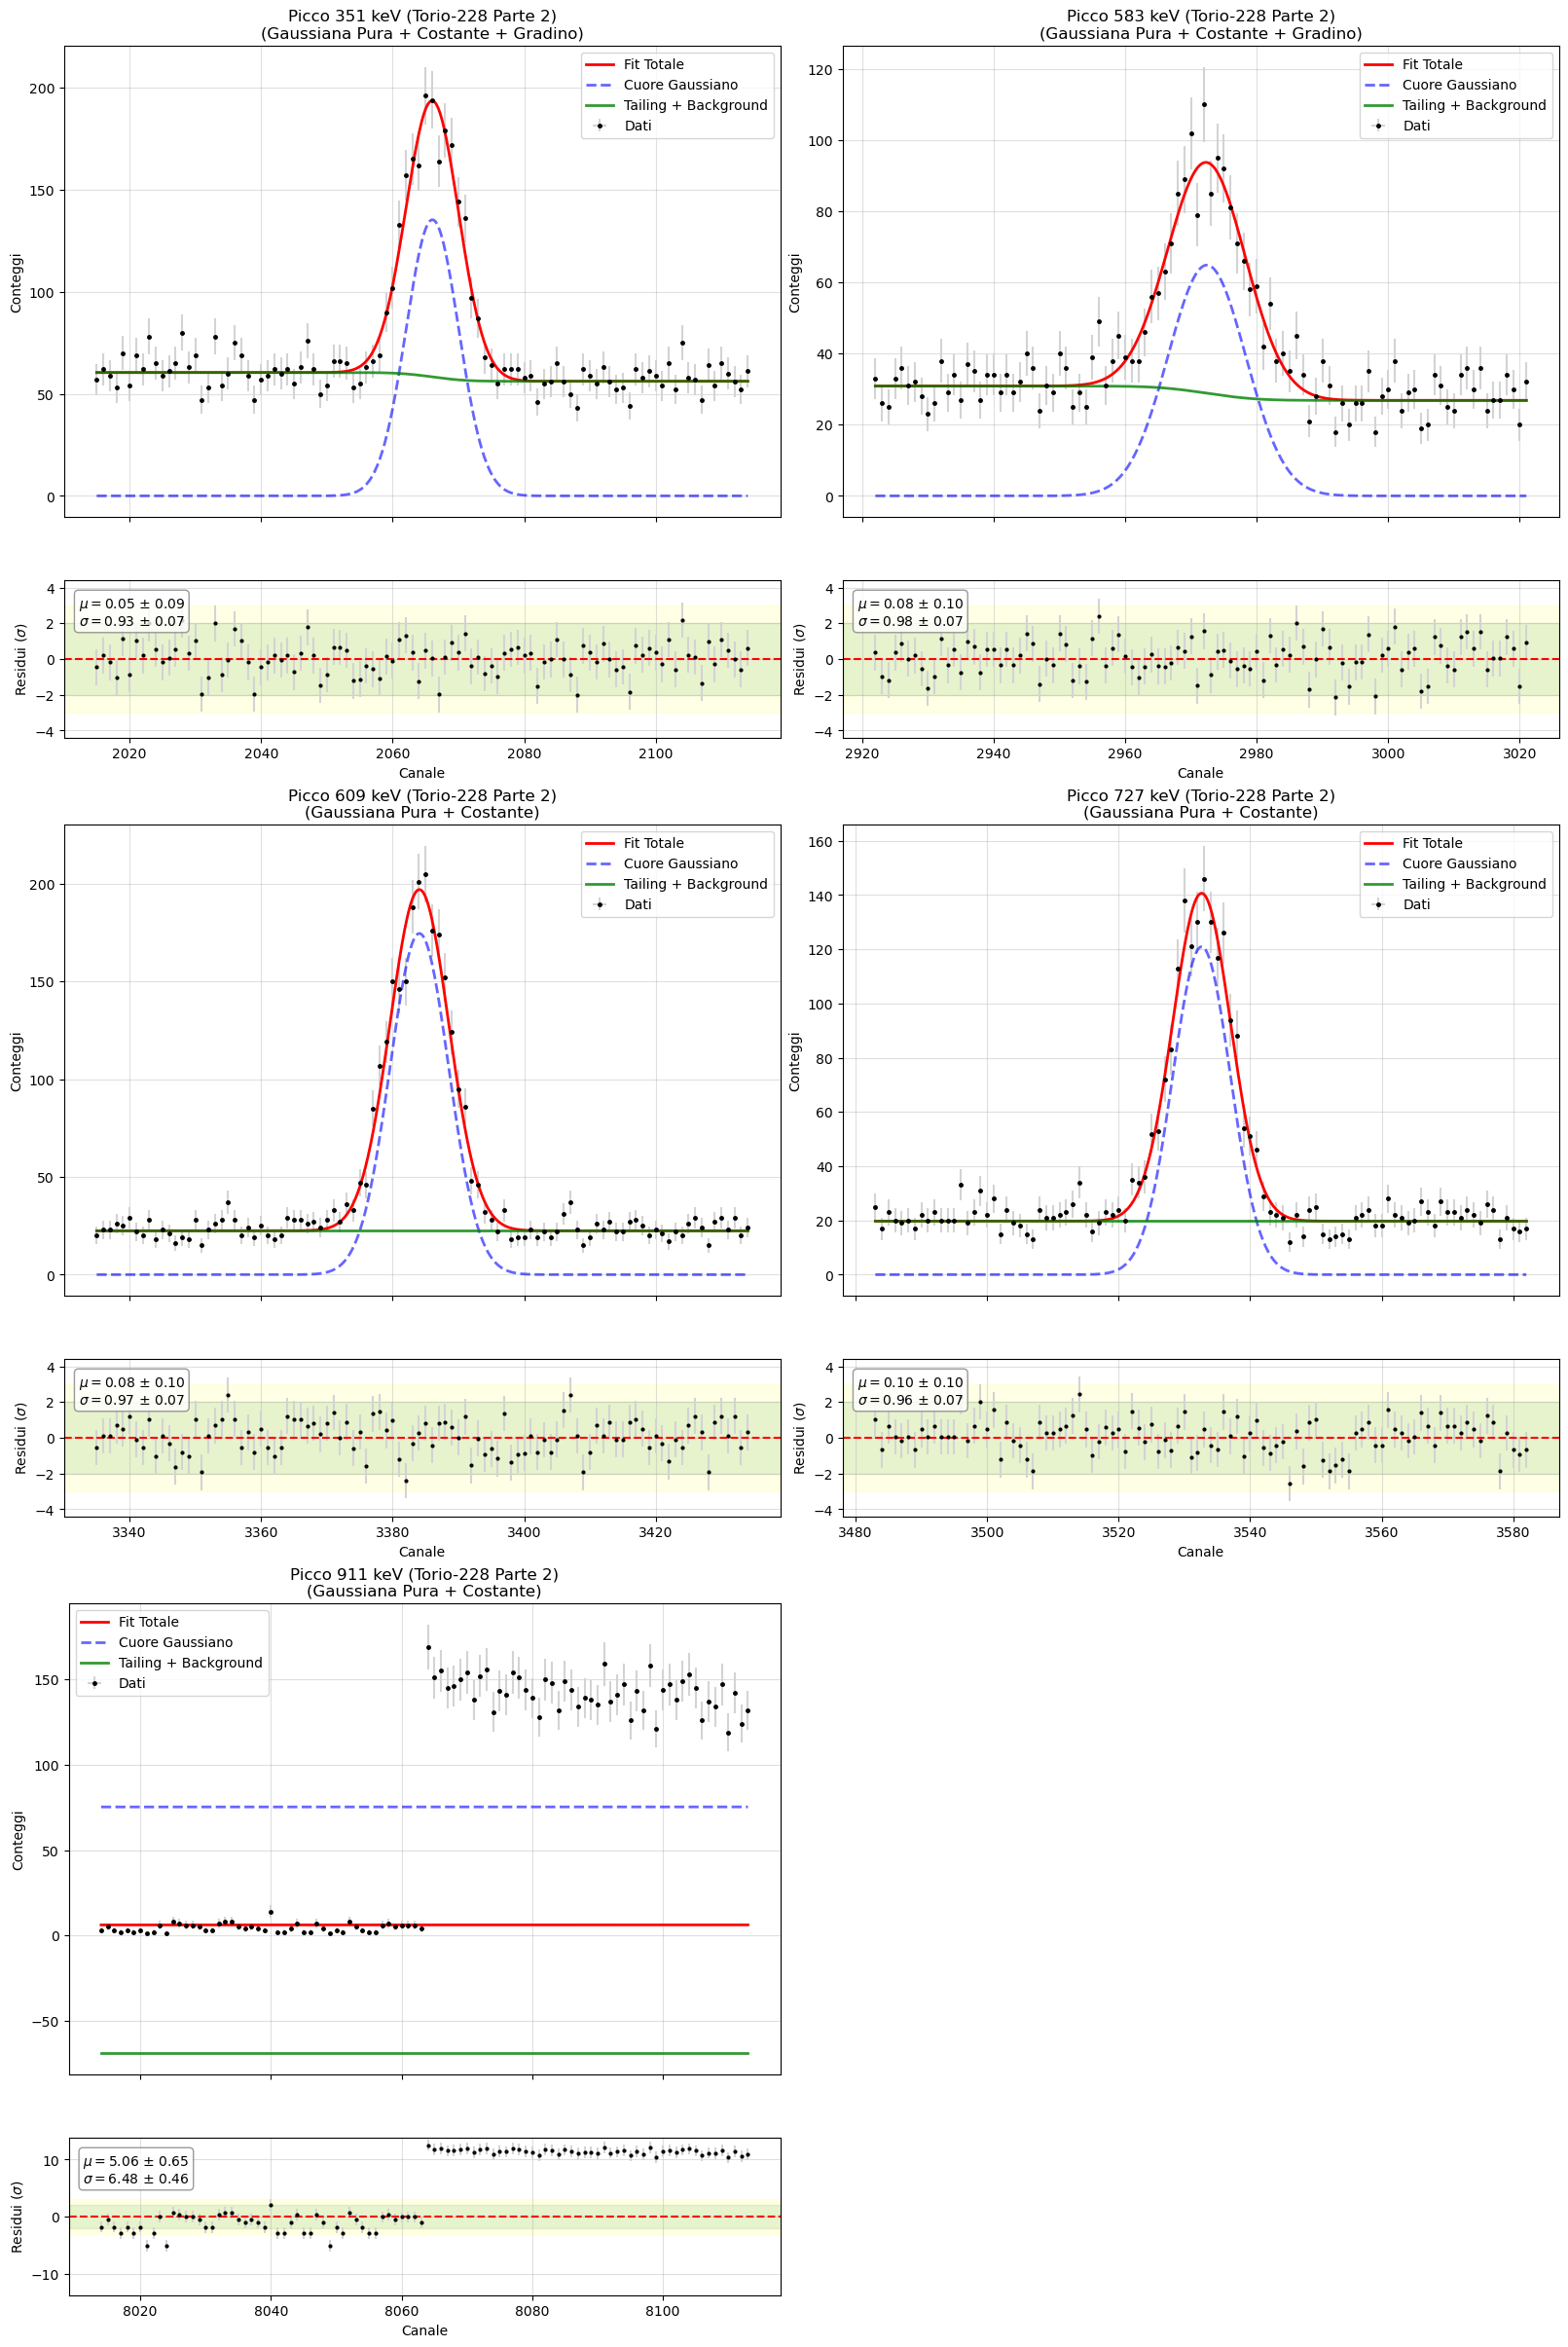

In [7]:
# --- ANALISI SODIO-22 (SUI CANALI) ---
print("--- Analisi Sodio-22 (SUI CANALI) ---")
canali_na = [2975, 7310] 

res_na = lmt.model_tournament_analisi_generale(
    data_na, 
    channels_na, 
    "Sodio-22", 
    energie_picchi_keV=canali_na, 
    err_energie_picchi_keV=[10, 10], 
    window_list=[40, 40], 
    verbose=True, 
    show_plots=True
)
# ESTRAZIONE AREE SODIO
aree_na, err_aree_na = res_na[8], res_na[9]


# --- ANALISI COBALTO-60 (SUI CANALI) ---
print("\n--- Analisi Cobalto-60 (SUI CANALI) ---")
canali_co = [6742, 7641]

res_co = lmt.model_tournament_analisi_generale(
    data_co, 
    channels_co, 
    "Cobalto-60", 
    energie_picchi_keV=canali_co,
    err_energie_picchi_keV=[10, 10],
    window_list=[40, 40],
    verbose=True, 
    show_plots=True
)
# ESTRAZIONE AREE COBALTO
aree_co, err_aree_co = res_co[8], res_co[9]


# --- ANALISI TORIO-228 + FONDO (Parte 1 e 2) ---
print("\n--- Analisi Torio-228 Parte 1 ---")
energie_th_1 = [238.632, 295.224]
err_th_1 = [0.002, 0.002]

res_th_1 = lmt.model_tournament_analisi_generale(
    data_th, channels_th, "Torio-228 Parte 1", 
    energie_th_1, err_th_1,
    [40, 40], 
    n_first_channels_to_ignore=500, prominence=20, distance=100,
    max_channel=2000
)

print("\n--- Analisi Torio-228 Parte 2 ---")
energie_th_2 = [351.932, 583.187, 609.312, 727.330, 911.196]
err_th_2 = [0.002, 0.002, 0.007, 0.009, 0.006]

res_th_2 = lmt.model_tournament_analisi_generale(
    data_th, channels_th, "Torio-228 Parte 2", 
    energie_th_2, err_th_2,
    [50, 50, 50, 50, 50], 
    n_first_channels_to_ignore=2000, prominence=20, distance=100
)

# ESTRAZIONE AREE TORIO (Unione delle due parti)
aree_th = list(res_th_1[8]) + list(res_th_2[8])
err_aree_th = list(res_th_1[9]) + list(res_th_2[9])
energie_finali_th = energie_th_1 + energie_th_2

In [8]:
# --- RACCOLTA RISULTATI E CALCOLO EFFICIENZE ---
efficienze_finali = []

# --- FILTRO TORIO ---
# aree_th contiene: [238, 295, 351, 583, 609, 727, 911]
# Per sicurezza, creiamo delle sottoliste "pulite" per il Torio:

aree_th_pulite = [aree_th[0], aree_th[3], aree_th[5]] # Esempio: 238, 583, 727
err_th_pulite = [err_aree_th[0], err_aree_th[3], err_aree_th[5]]
energie_th_pulite = [238.6, 583.2, 727.3]
br_th_pulite = [0.436, 0.306, 0.0658]

# Configurazione (ID, Aree, Errore_Aree, Energie, BranchingRatio, LiveTime_ms)
setup = [
    ('22Na', aree_na, err_aree_na, [511.0, 1274.5], [1.798, 0.999], INFO_SORGENTI['22Na']['t_live_ms']),
    ('60Co', aree_co, err_aree_co, [1173.2, 1332.5], [0.998, 0.999], INFO_SORGENTI['60Co']['t_live_ms']),
    ('228Th', aree_th_pulite, err_th_pulite, energie_th_pulite, br_th_pulite, INFO_SORGENTI['228Th']['t_live_ms'])
]

for isoid, aree, err_aree, ener, brs, t_ms in setup:
    A_t = get_attivita_oggi(isoid, DATA_MISURA) 
    t_sec = t_ms / 1000.0                       
    
    for i in range(len(ener)):
        # Calcolo Efficienza
        eff = aree[i] / (A_t * brs[i] * t_sec)
        
        # Calcolo Errore
        rel_err_area = err_aree[i] / aree[i]
        err_eff = eff * rel_err_area
        
        efficienze_finali.append({
            'Isotopo': isoid,
            'Energia [keV]': ener[i],
            'Efficienza': eff,
            'Errore': err_eff
        })

# Creazione DataFrame
df_risultati = pd.DataFrame(efficienze_finali)
print("\n--- TABELLA EFFICIENZE AGGIORNATA ---")
print(df_risultati.to_string(index=False))


--- TABELLA EFFICIENZE AGGIORNATA ---
Isotopo  Energia [keV]  Efficienza   Errore
   22Na          511.0    0.000260 0.000006
   22Na         1274.5    0.000123 0.000001
   60Co         1173.2    0.000276 0.000008
   60Co         1332.5    0.000245 0.000002
  228Th          238.6    0.000369 0.000008
  228Th          583.2    0.000111 0.000006
  228Th          727.3    0.000717 0.000024


In [9]:
import numpy as np

# Prendiamo i dati dal DataFrame filtrando via il punto "matto" a 727 keV
# e tenendo solo quelli fisicamente coerenti
df_fit = df_risultati[df_risultati['Energia [keV]'] != 727.3].copy()

# Prepariamo le x (Energia) e le y (Efficienza)
x_data = df_fit['Energia [keV]'].values
y_data = df_fit['Efficienza'].values
y_err = df_fit['Errore'].values

# Trasformazione Log-Log (fondamentale per la formula parabolica dell'efficienza)
log_x = np.log(x_data)
log_y = np.log(y_data)

# Errore sui logaritmi (propagazione: sigma_logy = sigma_y / y)
log_y_err = y_err / y_data

print("Dati pronti per il fit!")
print(f"Punti utilizzati: {len(x_data)}")

Dati pronti per il fit!
Punti utilizzati: 6


In [10]:
from scipy.optimize import curve_fit

def parabola(lnE, a, b, c):
    return a + b*lnE + c*(lnE**2)

# Fit pesato con gli errori
popt, pcov = curve_fit(parabola, log_x, log_y, sigma=log_y_err, p0=[1, -1, 0.1])

a_fit, b_fit, c_fit = popt
print(f"Parametri trovati:\na = {a_fit:.4f}\nb = {b_fit:.4f}\nc = {c_fit:.4f}")

Parametri trovati:
a = 17.9827
b = -8.0211
c = 0.6034


<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\c'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:34: SyntaxWarning: invalid escape sequence '\l'
<>:49: SyntaxWarning: invalid escape sequence '\p'
<>:50: SyntaxWarning: invalid escape sequence '\p'
<>:51: SyntaxWarning: invalid escape sequence '\p'
<>:52: SyntaxWarning: invalid escape sequence '\c'
C:\Users\Anna\AppData\Local\Temp\ipykernel_26720\2216200109.py:34: SyntaxWarning: invalid escape sequence '\l'
  label=f'Fit: $\ln(\epsilon) = {a_fit:.2f} {b_fit:+.2f}\ln(E) {c_fit:+.2f}\ln^2(E)$')
C:\Users\Anna\AppData\Local\Temp\ipykernel_26720\2216200109.py:34: SyntaxWarning: invali

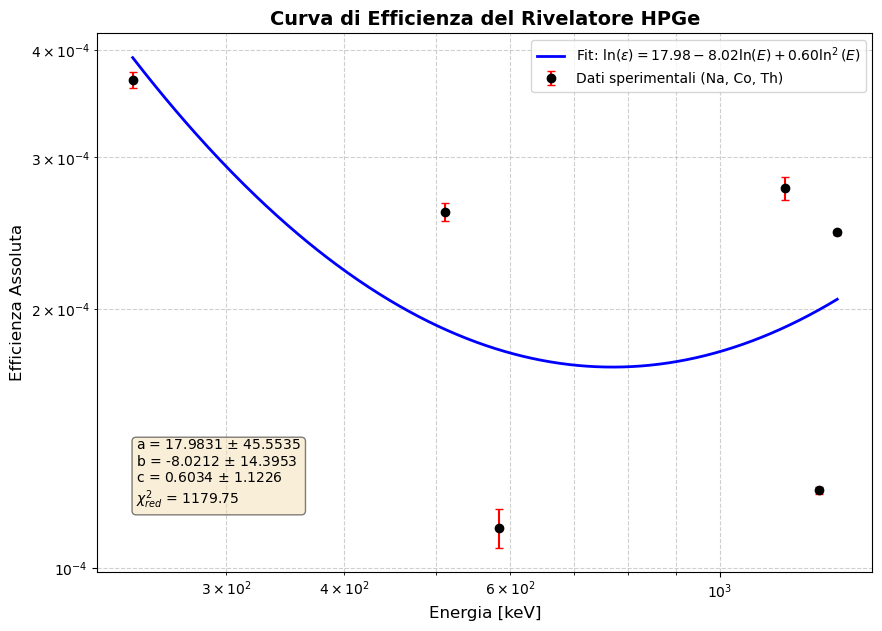

Fit completato.
Chi-quadro ridotto: 1179.746


In [11]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit

# 1. Definizione della funzione teorica (parabola nel piano log-log)
def parabola(lnE, a, b, c):
    return a + b*lnE + c*(lnE**2)

# 2. Esecuzione del Fit
# p0 è la stima iniziale: a (altezza), b (pendenza negativa), c (curvatura)
popt, pcov = curve_fit(parabola, log_x, log_y, sigma=log_y_err, p0=[1, -1, 0.05])
a_fit, b_fit, c_fit = popt
perr = np.sqrt(np.diag(pcov)) # Errori sui parametri

# 3. Calcolo del Chi-Quadro ridotto
residui = log_y - parabola(log_x, *popt)
chi_quadro = np.sum((residui / log_y_err)**2)
gradi_liberta = len(log_x) - len(popt)
chi_ridotto = chi_quadro / gradi_liberta

# 4. Generazione della curva continua per il grafico
x_fit = np.linspace(x_data.min(), x_data.max(), 500)
y_fit = np.exp(parabola(np.log(x_fit), *popt))

# 5. Visualizzazione (Disegno)
plt.figure(figsize=(10, 7))

# Disegno i punti sperimentali con le barre d'errore
plt.errorbar(x_data, y_data, yerr=y_err, fmt='o', markersize=6, color='black', 
             ecolor='red', capsize=3, label='Dati sperimentali (Na, Co, Th)')

# Disegno la curva di fit
plt.plot(x_fit, y_fit, '-', color='blue', linewidth=2, 
         label=f'Fit: $\ln(\epsilon) = {a_fit:.2f} {b_fit:+.2f}\ln(E) {c_fit:+.2f}\ln^2(E)$')

# Formattazione assi Log-Log
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.6)

# Titoli e legende
plt.title('Curva di Efficienza del Rivelatore HPGe', fontsize=14, fontweight='bold')
plt.xlabel('Energia [keV]', fontsize=12)
plt.ylabel('Efficienza Assoluta', fontsize=12)
plt.legend(loc='best', fontsize=10)

# Inserisco i risultati del fit in un box nel grafico
textstr = '\n'.join((
    f'a = {a_fit:.4f} $\pm$ {perr[0]:.4f}',
    f'b = {b_fit:.4f} $\pm$ {perr[1]:.4f}',
    f'c = {c_fit:.4f} $\pm$ {perr[2]:.4f}',
    f'$\chi^2_{{red}}$ = {chi_ridotto:.2f}'
))
props = dict(boxstyle='round', facecolor='wheat', alpha=0.5)
plt.text(0.05, 0.25, textstr, transform=plt.gca().transAxes, fontsize=10, verticalalignment='top', bbox=props)

plt.show()

print(f"Fit completato.\nChi-quadro ridotto: {chi_ridotto:.3f}")